In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
!pip install dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 6.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: dacite
    Found existing installation: dacite 1.9.2
    Uninstalling dacite-1.9.2:
      Successfully uninstalled dacite-1.9.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires dacite<2,>=1.9, but you have dacite 1.6.0 which is incompatible.


In [9]:
%pip install -q dagshub mlflow


Note: you may need to restart the kernel to use updated packages.


In [10]:
import dagshub
dagshub.init(repo_owner='mesata', repo_name='IEE-CIS-Fraud-Detection', mlflow=True)

import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

Initialized MLflow to track repo "mesata/IEE-CIS-Fraud-Detection"

Repository mesata/IEE-CIS-Fraud-Detection initialized!

🏃 View run unique-frog-270 at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/6c2fa6f14032467ea2e003d163e43bd4
🧪 View experiment at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/0


# FEATURE ENGINEERING

In [15]:
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

In [16]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

In [18]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


/tmp/ipykernel_57/3567332771.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=train[train['isFraud'] == 0], x='TransactionHour', label='Legit', shade=True, color='pink')
/tmp/ipykernel_57/3567332771.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=train[train['isFraud'] == 1], x='TransactionHour', label='Fraud', shade=True, color='purple')


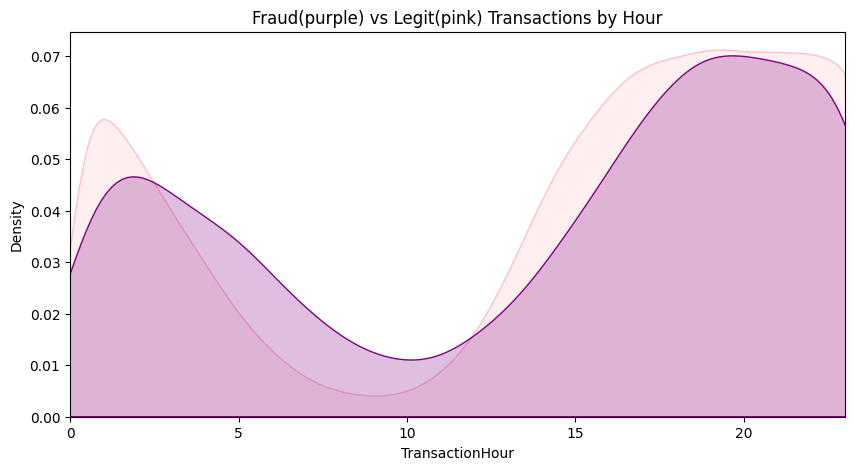

In [24]:
train['TransactionHour'] = (train['TransactionDT'] / 3600) % 24
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
sns.kdeplot(data=train[train['isFraud'] == 0], x='TransactionHour', label='Legit', shade=True, color='pink')
sns.kdeplot(data=train[train['isFraud'] == 1], x='TransactionHour', label='Fraud', shade=True, color='purple')
plt.xlim(0, 23) 
plt.title('Fraud(purple) vs Legit(pink) Transactions by Hour')
plt.show()

დაახლოებით 5-10 საათის შუალედში, როცა მოსახლეობას მშვიდად სძინავს, ხდება ყველაზე მეტი თაღლითობა ტრანზაქციებთან შედარებით (სხვაობა დიდია). ყველაზე მეტი თაღლითობა კი რაოდენობრივად ხდება საღამოს. აქ მაღალია ვალიდური გადარიცხვებიც და კარგად დაიმალება.  

In [25]:
from sklearn.preprocessing import LabelEncoder
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))

print(f"Encrypted {len(cat_cols)} categorical columns.")

Encrypted 31 categorical columns.


# FEATURE SELECTION


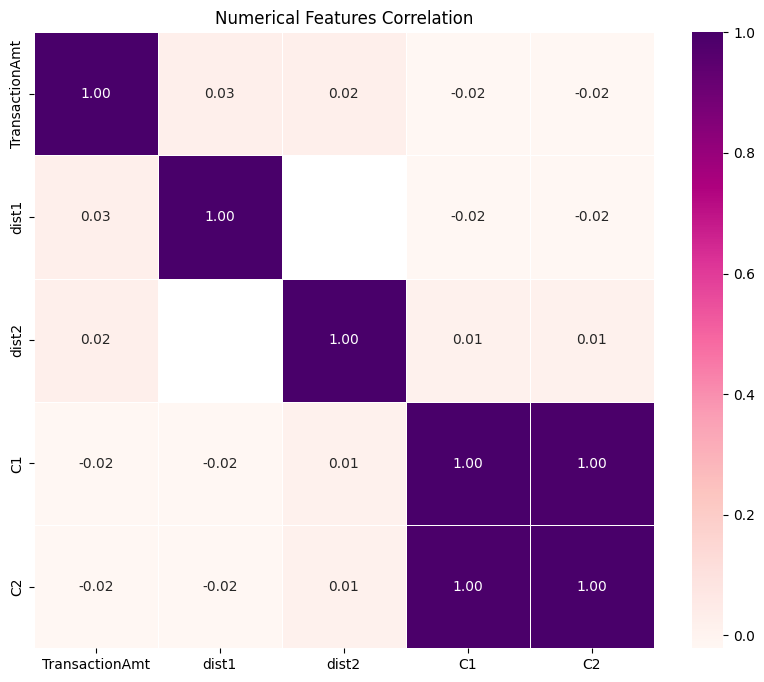

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(train[['TransactionAmt', 'dist1', 'dist2', 'C1', 'C2']].corr(), 
            annot=True, 
            cmap='RdPu', 
            fmt=".2f", 
            linewidths=0.5)

plt.title("Numerical Features Correlation")
plt.show()

1 კორელაცია c1-c2 შორის. იგივე ტიპებია, დავტოვებ c1ს. 

/tmp/ipykernel_57/3932575184.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nan_stats[:20].index, y=nan_stats[:20].values, palette='RdPu_r')


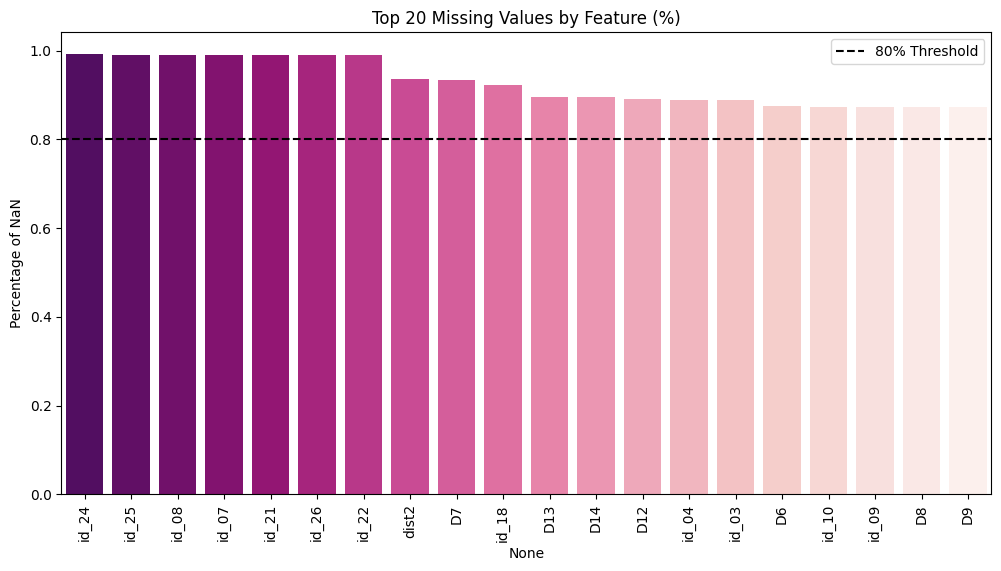

In [26]:
nan_stats = train.isnull().mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_stats[:20].index, y=nan_stats[:20].values, palette='RdPu_r')
plt.xticks(rotation=90)
plt.axhline(y=0.8, color='black', linestyle='--', label='80% Threshold')
plt.title('Top 20 Missing Values by Feature (%)')
plt.ylabel('Percentage of NaN')
plt.legend()
plt.show()

80%ზე მეტი მონაცემი რომელსაც აკლია, წავშლი. 

In [27]:
cols_to_drop = nan_stats[nan_stats > 0.8].index
final_cols_to_drop = list(cols_to_drop) + ['TransactionID', 'TransactionDT', 'C2']
X = train.drop(columns=['isFraud'] + final_cols_to_drop)
y = train['isFraud']
print(f"საბოლოოდ დაგვრჩა {X.shape[1]} სვეტი.")

საბოლოოდ დაგვრჩა 362 სვეტი.


In [32]:
from sklearn.feature_selection import VarianceThreshold

# 1. მხოლოდ რიცხვითი სვეტების შერჩევა (ვარიაცია ტექსტზე არ მუშაობს)
numeric_cols = X.select_dtypes(include=['number']).columns

# 2. ვარიაციის ფილტრის შექმნა
# threshold=0.01 ნიშნავს, რომ თუ სვეტის მონაცემების 99%-ზე მეტი იდენტურია, მას ვაგდებთ
selector = VarianceThreshold(threshold=0.01)
selector.fit(X[numeric_cols])

# 3. იმ სვეტების პოვნა, რომლებიც უნდა დავტოვოთ
features_to_keep = numeric_cols[selector.get_support()]

# 4. X-ის განახლება (ვტოვებთ შერჩეულ რიცხვით სვეტებს + ყველა კატეგორიულს, თუ ისინი დაგვჭირდა)
X = X[features_to_keep]

print(f"Low variance ფილტრის შემდეგ დაგვრჩა {X.shape[1]} სვეტი.")

Low variance ფილტრის შემდეგ დაგვრჩა 338 სვეტი.


In [33]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X = X.drop(columns=to_drop)
print(f"მაღალი კორელაციის გამო წაიშალა {len(to_drop)} სვეტი.")
print(f"საბოლოო სვეტების რაოდენობა: {X.shape[1]}")

მაღალი კორელაციის გამო წაიშალა 109 სვეტი.
საბოლოო სვეტების რაოდენობა: 229


ამან cpu მოკლა მაგრამ შემდგომი მკვლელობისგან იხსნა. 

# TRAINING

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

print("მონაცემები გაიყო წარმატებით!")
print(f"X_train shape: {X_train.shape}")

მონაცემები გაიყო წარმატებით!
X_train shape: (472432, 229)


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

mlflow.set_experiment("Fraud_Detection_Baseline_Regression")
with mlflow.start_run(run_name="Logistic_Optimized_Final"):
    pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=100, solver='lbfgs', random_state=42)) # solver შეიცვალა
])
    
    print("Training")
    pipeline.fit(X_train, y_train)
    y_pred_proba = pipeline.predict_proba(X_val)[:, 1]
    auc_score = roc_auc_score(y_val, y_pred_proba)
    mlflow.log_param("final_features_count", X.shape[1])
    mlflow.log_metric("auc_score", auc_score)
    mlflow.sklearn.log_model(pipeline, "logistic_model")
    print(f"Done. Validation AUC Score: {auc_score:.4f}")

Training


2026/05/02 20:05:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/02 20:05:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Done. Validation AUC Score: 0.8042
🏃 View run Logistic_Optimized_Final at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/53ee726817f248a5a16e841c82dfd468
🧪 View experiment at: https://dagshub.com/mesata/IEE-CIS-Fraud-Detection.mlflow/#/experiments/1


/tmp/ipykernel_57/1623774035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='RdPu_r')


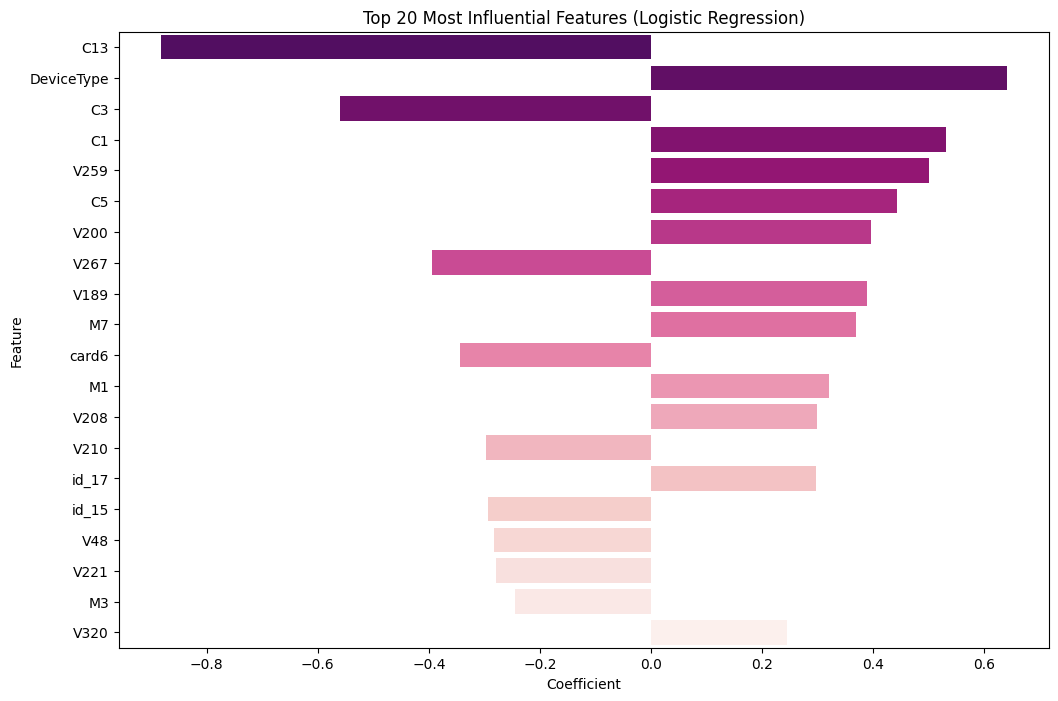

In [43]:
coefs = pipeline.named_steps['model'].coef_[0]
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})
importance_df['Abs_Coef'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coef', ascending=False).head(20)
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='RdPu_r')
plt.title('Top 20 Most Influential Features (Logistic Regression)')
plt.show()

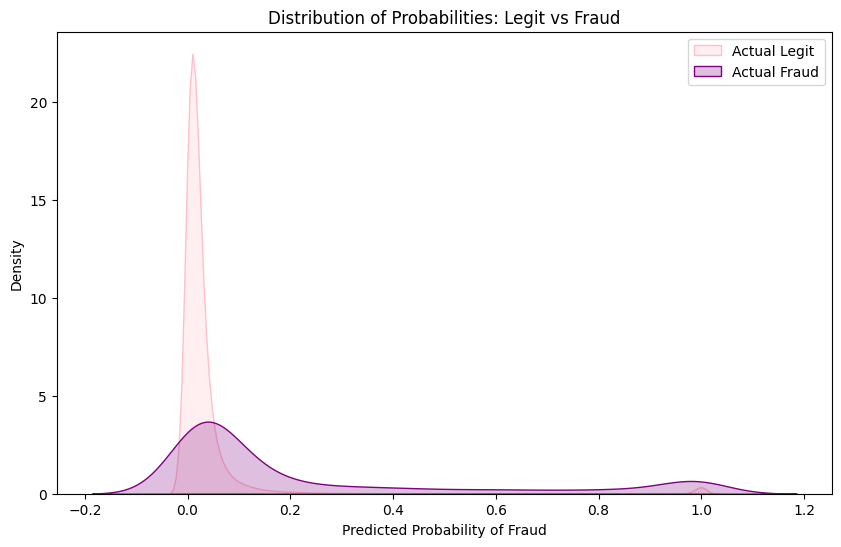

In [44]:
plt.figure(figsize=(10, 6))
sns.kdeplot(y_pred_proba[y_val == 0], label='Actual Legit', fill=True, color="pink")
sns.kdeplot(y_pred_proba[y_val == 1], label='Actual Fraud', fill=True, color="purple")
plt.xlabel('Predicted Probability of Fraud')
plt.title('Distribution of Probabilities: Legit vs Fraud')
plt.legend()
plt.show()